In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from scipy.constants import k
from sklearn.linear_model import LinearRegression

files = sorted(glob("testing*.csv"))[1:]

In [16]:
# the final temperature from a uniformly distributed speed
m = 1
v_max = 0.5

T_f = (m * v_max**2 / (9 * k))


def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * k * T))**(3/2) * np.exp(- m * v**2 / (2 * k * T))


def f_M_v(v, T, m):
  return (m / (2 * np.pi * k * T))**(1/2) * np.exp(- m * v**2 / (2 * k * T))

In [17]:
omega = 1
alpha = 2.13986
mu_inf_mu_1 = 1
mu_ref = 21.27e-6
m = 6.6e-26

T_x = 373
T_yz = 273
T_f = (2 * 273 + 373) / 3
T_ref = T_f


Pr = 1
ratio = alpha * (5 - 2 * omega) * (7 - 2 * omega) * Pr / (5 * (alpha + 1) * (alpha + 2) * (mu_inf_mu_1))
print(ratio)

speed_range = np.linspace(0, 1, 1000)
n = 1
sigma = 1
nu_c = n
nu = nu_c * ratio

m = 6.6e-26
v_range = np.linspace(-1e3, 1e3, 1000)

0.4938677605727688


In [18]:
def getGrowthRate(path : str, start_time_step=10, end_time_step=110, step_size=10, dt=5e-2, fitting_start_index=0,fitting_stop_index=5):
  errors = [[], [], []]
  fits = []
  rates = np.zeros(3)
  components = ["x", "y", "z"]
  time = (np.arange(start_time_step, end_time_step, step_size) * dt)
  start_idx = fitting_start_index
  stop_idx = fitting_stop_index
  fitting_time = time[start_idx:stop_idx].reshape((-1, 1))

  for i in range(start_time_step, end_time_step, step_size):

    data = pd.read_csv(f"{path:s}/testing_csv_distribution_{i:04d}.csv")

    for i, c in enumerate(components):
      centers = ((data[f"v_{c:s}_lower"] + data[f"v_{c:s}_upper"]) / 2).to_numpy()
      counts = data[f"v_{c:s}"]
      total = np.trapezoid(counts, centers)
      pdf = counts / total
      errors[i].append(np.linalg.norm((pdf - f_M_v(centers, T_f, m)))/np.linalg.norm(f_M_v(centers, T_f, m)))

  for i, _ in enumerate(components):
    curr_error = np.array(errors[i])
    fitting_data = np.log(curr_error[start_idx:stop_idx]).reshape((-1, 1))
    fit = LinearRegression().fit(fitting_time,fitting_data)
    rates[i] = abs(fit.coef_[0][0])
    fits.append(fit)

  return time, errors, fitting_time, fits, rates

Actual Relaxation Rate: 0.4939

Particles Per Element : 400
Relaxation Rate       : 0.0854 +- 0.0000
Relaxation Error      : 82.7157%
Relaxation Rate       : 0.1813 +- 0.0000
Relaxation Error      : 63.2979%
Relaxation Rate       : 0.2221 +- 0.0000
Relaxation Error      : 55.0300%
Mean Rate             : 0.1629 +- 0.0573
Mean Error            : 0.6701%



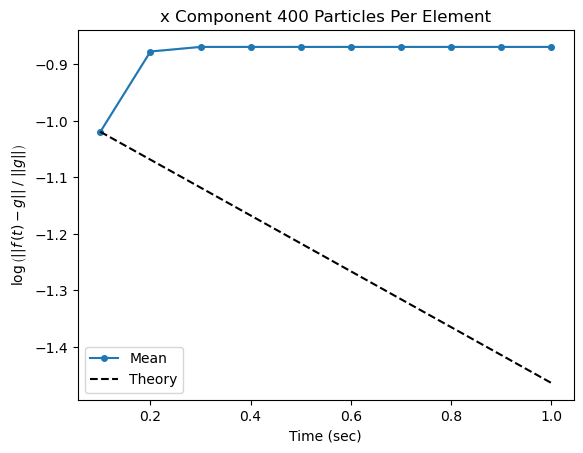

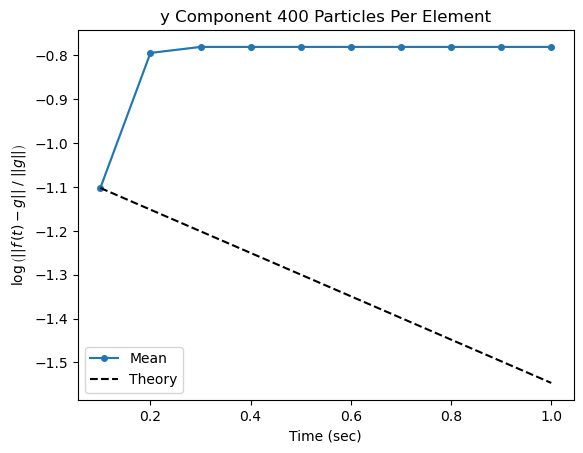

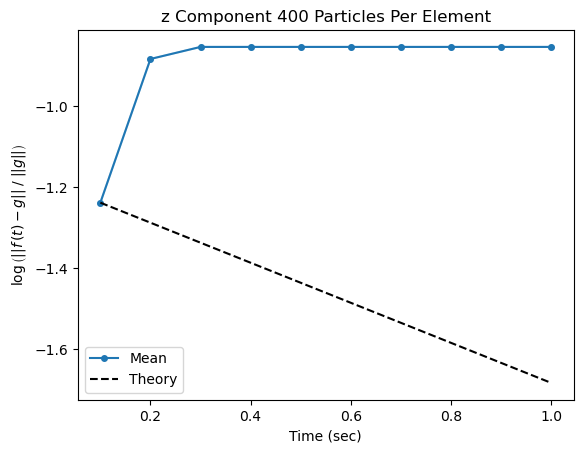

In [19]:
runs = 1
start_idx = 0
stop_idx = 10
# ppe = (int)(1e3)
ppes = [400]

components = ["x", "y", "z"]


print(f"Actual Relaxation Rate: {nu:0.4f}")
print()
for j, ppe in enumerate(ppes):
  fig_1, axs_1 = plt.subplots(1,1)
  fig_2, axs_2 = plt.subplots(1,1)
  fig_3, axs_3 = plt.subplots(1,1)
  axes = [axs_1, axs_2, axs_3]
  all_rates = []
  print(f"Particles Per Element : {ppe:d}")
  file_path = "./"
  # file_path = f"relax_study_random_round/100x100/{ppe:d}/run"
  mean_errors = [[], [], []]
  mean_rate = [[],[],[]]
  used_runs = 0
  for i in range(runs):
    time, errors, fitting_time, fits, rates = getGrowthRate(f"{file_path:s}", dt=1e-2, fitting_start_index=start_idx, fitting_stop_index=stop_idx)

    for j, c in enumerate(components):
      if i == 0:
        mean_errors[j] = np.zeros_like(time)
      all_rates.append(rates[j])
      axes[j].plot(time, np.log(errors[j]), '-o', markersize=4, alpha=0.2)
      mean_errors[j] += errors[j]
      mean_rate[j].append(rates[j])

  for i, c in enumerate(components):
    mean_rate[i] = np.array(mean_rate[i])
    print(f"Relaxation Rate       : {mean_rate[i].mean():0.4f} +- {mean_rate[i].std():0.4f}")
    print(f"Relaxation Error      : {100 * abs(mean_rate[i].mean() - nu) / nu:0.4f}%")
    axes[i].plot(time, np.log(mean_errors[i] / runs), '-o', color='tab:blue', markersize=4, label="Mean")
    axes[i].plot(time, -nu * (time - time[0]) + np.log(mean_errors[i][0] / runs), 'k--', label='Theory')
    axes[i].set_title(f"{c:s} Component {ppe:d} Particles Per Element")
    axes[i].set_xlabel("Time (sec)")
    axes[i].set_ylabel("$\\log\\left(||f\\,(t) - g|| \\; / \\; ||g|| \\right)$")
    axes[i].legend()

  all_rates = np.array(all_rates)
  print(f"Mean Rate             : {all_rates.mean():0.4f} +- {all_rates.std():0.4f}")
  print(f"Mean Error            : {abs(all_rates.mean() - nu) / nu:0.4f}%")
  print()